<a href="https://colab.research.google.com/github/Tuchobm/Curso-IA-Google-Colab/blob/main/5_2_entrenamiento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 2: Entremaiento de un LLM

En este ejercicio, aprenderás a entrenar un modelo de lenguaje grande (LLM) utilizando la biblioteca `transformers` de Hugging Face. Utilizaremos el modelo Llama 3.2-1B-Instruct, que es un modelo de lenguaje preentrenado diseñado para tareas de generación de texto.

Además, encontrarás partes del código contendrán el comentario de '# ACTIVIDAD' que indican dónde debes completar el código o realizar tareas específicas. Asegúrate de seguir las instrucciones y completar el código donde se indique.

# Instalar dependencias necesarias

Una vez que hayas instalados las siguientes librerías, asegúrate de reiniciar el kernel para que los cambios surtan efecto. Puedes hacerlo desde el menú "Kernel" en Jupyter Notebook, Google Colab o Kaggle.

In [ ]:
!pip install -U datasets
!pip install bitsandbytes peft

# Importar librerias


In [ ]:
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

## Cargar dataset

### Google Colab

Descargar el dataset de [Google Drive](https://drive.google.com/file/d/1hTFL6PDVeixdTjn_vVFhGn4xo3qO5GEE/view?usp=sharing) y subirlo a Google Colab.

Link: https://drive.google.com/file/d/1hTFL6PDVeixdTjn_vVFhGn4xo3qO5GEE/view?usp=sharing

Codigo para cargar el dataset:

```python
df = pd.read_csv("sentiment_analysis.csv")
```
### Kaggle

Si estás utilizando Kaggle, puedes cargar el dataset directamente desde Kaggle. Asegúrate de que el dataset esté disponible en tu entorno de Kaggle. En caso de que no esté disponible, clica en el apartado de "add input" (arriba a la derecha) y selecciona el siguiente dataset:

Link: https://www.kaggle.com/datasets/fsanchezizertis/sentiment-analysis

Codigo para cargar el dataset:
```python
df = pd.read_csv("/kaggle/input/sentiment-analysis/sentiment_analysis.csv")
```

In [ ]:
# Google Colab
df = pd.read_csv("")

id2label = {0: "negativo", 1: "positivo"}
label2id = {"negativo": 0, "positivo": 1}

df_train, df_test = train_test_split(df, test_size=0.2, random_state=0)
df_train, df_val = train_test_split(df_train, test_size=0.2, random_state=0)

train = Dataset.from_pandas(df_train)
validation = Dataset.from_pandas(df_val)
test = Dataset.from_pandas(df_test)
dataset = DatasetDict({"train": train, "validation": validation, "test": test})

## Exploración de datos

Intenta observar si hay algún patrón en los datos. Similar a los ejercicios anteriores, puedes usar `matplotlib` o `seaborn` para visualizar los datos. Alternativamente, puedes usar `pandas` directamente para observar los datos.

Recomendaciones de visualización:
- Frequencias de las clases
- Distribución de numeros de palabras, opcionalmente por clase
- Distribución de numeros de caracteres, opcionalmente por clase
- Observar si hay caracteres que no son letras o números

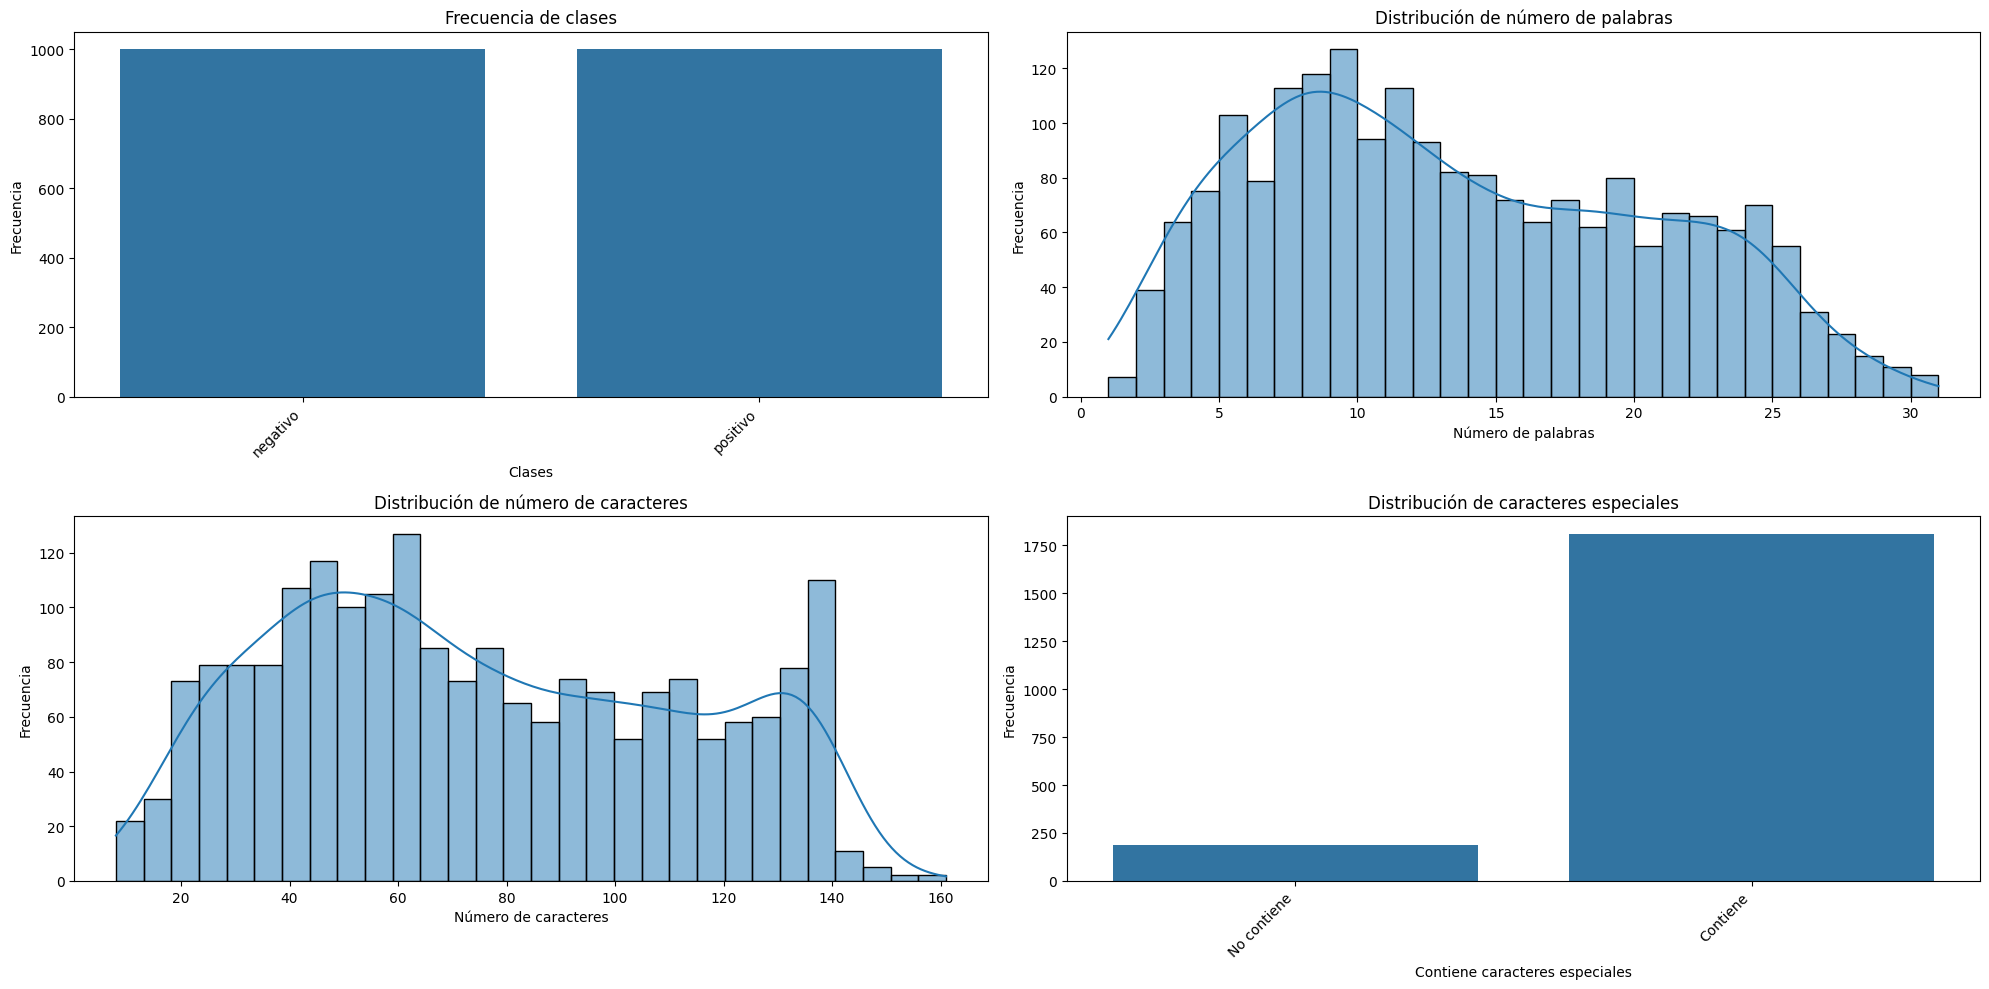

In [ ]:
# ACTIVIDAD: Explorar dataset

## Preprocesamiento

El preprocesamiento de los datos es una parte importante del proceso de entrenamiento de un modelo de lenguaje. Una vez que hayas explorado los datos y tengas una idea de cómo se ven, puedes comenzar a preprocesarlos. Prueba de eliminar los siguientes caracteres:
- Caracteres especiales
- Espacios en blanco duplicados
- Convertir a minúsculas
- Eliminar números

Puedes probar más

Antes de realizar el preprocesamiento, comprueba el rendimiento del modelo sin preprocesar los datos. Esto te permitirá observar si el preprocesamiento mejora el rendimiento del modelo o no.

In [ ]:
import re

NO_CARACTER_ESPECIALES = r"[a-zA-Z0-9\s]"

def eliminar_caracteres_especiales(texto):
    return re.sub(NO_CARACTER_ESPECIALES, "", texto)

# ACTIVIDAD AVANZADA (OPCIONAL): Preprocesar dataset
def eliminar_espacios_extra(texto):
    return texto


def convertir_minusculas(texto):
    return texto


def eliminar_numeros(texto):
    return texto


def limpieza(data):
    texto = data["text"]
    texto = eliminar_caracteres_especiales(texto)
    texto = eliminar_espacios_extra(texto)
    texto = convertir_minusculas(texto)
    texto = eliminar_numeros(texto)
    data["text"] = texto
    return data


train = train.map(limpieza, batched=False)
validation = validation.map(limpieza, batched=False)
test = test.map(limpieza, batched=False)

dataset = DatasetDict({"train": train, "validation": validation, "test": test})

## Preparación del modelo a entrenar

In [ ]:
model_name = "unsloth/Llama-3.2-1B-Instruct"

# Configuramos QLoRA para el modelo
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

lora_config = LoraConfig(
    r=16,
    lora_alpha=8,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="SEQ_CLS",
)

# Cargamos el modelo y el tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    quantization_config=quantization_config,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)
model

In [ ]:
model = prepare_model_for_kbit_training(model)
model

In [ ]:
model = get_peft_model(model, lora_config)
model

In [ ]:
# Configuramos el tokenizer y la configuración del modelo
tokenizer = AutoTokenizer.from_pretrained(model_name, add_prefix_space=True)

tokenizer.pad_token = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id

model.config.pad_token_id = tokenizer.pad_token_id
model.config.pretraining_tp = 1
model.config.use_cache = False

In [ ]:
# Tamaño máximo de un tweet (dejamos mas por si hay algun error)
MAX_LEN = 512


def llama_preprocessing_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LEN)


tokenized_datasets = dataset.map(llama_preprocessing_function, batched=True)
tokenized_datasets = tokenized_datasets.rename_column("target", "label")

tokenized_datasets.set_format("torch")

## Entrenamiento del modelo

In [ ]:
from sklearn.metrics import accuracy_score


def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    predictions = predictions.argmax(-1)
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc}

In [ ]:
training_args = TrainingArguments(
    output_dir="./models/Llama-3.2-1B-sentiment",
    learning_rate=1e-4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    metric_for_best_model="accuracy",
    load_best_model_at_end=True,
    report_to="none",
    logging_steps=20,
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
)

In [ ]:
train_results = trainer.train()

In [ ]:
metrics = train_results.metrics
max_train_samples = len(tokenized_datasets["train"])
metrics["train_samples"] = min(max_train_samples, len(tokenized_datasets["train"]))
trainer.log_metrics("train", metrics)
trainer.save_metrics("train", metrics)
trainer.save_state()

# Evaluación del modelo

In [ ]:
from sklearn.metrics import accuracy_score


def evaluate(model, tokenizer, test, device, batch_size=32):
    sentences = test["text"]

    all_preds = []

    for i in range(0, len(sentences), batch_size):
        batch = sentences[i : i + batch_size]
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            return_tensors="pt",
            max_length=MAX_LEN,
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1).cpu().numpy()
            all_preds.extend(preds)

    # Convert predictions to labels
    return [id2label[pred_id] for pred_id in all_preds]


# Evaluate the model on the test set
guesses = evaluate(model, tokenizer, test, device="cuda")
truth = [id2label[true_id] for true_id in test["target"]]
eval_accuracy = accuracy_score(truth, guesses)
print(f"Test Accuracy: {eval_accuracy:.4f}")

# Guardar el adaptador al mejor modelo

## Google Colab

Guarda el mejor modelo en tu Google Drive en la carpeta `trianed`

Utiliza el siguiente código para guardar el modelo en Google Drive:

```python
trained_model.save_pretrained('./models/Llama-3.2-1B-best-sentiment')
!cp -r ./models/Llama-3.2-1B-best-sentiment /content/drive/MyDrive/trained
```

Luego, podras observar el modelo en tu Google Drive en la carpeta `trained`.

## Kaggle

Utliza el siguiente código para guardar el modelo en Kaggle:

```python
trained_model.save_pretrained('./models/Llama-3.2-1B-best-sentiment')
!cp -r ./models/Llama-3.2-1B-best-sentiment /kaggle/working
!zip -r /kaggle/working/Llama-3.2-1B-best-sentiment.zip /kaggle/working/Llama-3.2-1B-best-sentiment
```

Tienes dos opciones para descargar el modelo:
1. Descargar el modelo directamente desde Kaggle a tu computadora. Lo puedes realizar desde la pestaña de "Output" (en medio a la derecha) y descargando el archivo `Llama-3.2-1B-best-sentiment.zip`.
2. Guardar version en el notebook, el boton de "Save version" (arriba a la derecha) y selecciondo en "Advanced settings" la opción de "Run with GPU for this session". Esto volvera a ejecutar el notebook y te generara una version con del notebook. Una vez que se haya guardado la version, puedes ver el modelo en el final del notebook, en la sección de "Output".